# 3 — The target list

Scoring 156,107 companies produces a ranking. It does not yet produce a **call list**, and the gap
between the two is where most lead-scoring work quietly fails.

In [1]:
import pandas as pd

import config
import pipeline

pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 46)

accounts = pd.read_csv(config.OUTPUT_DIR + "/scored_segment.csv")
print(f"{len(accounts):,} ranked accounts")

136,542 ranked accounts


## The special-purpose vehicle problem

The first ranked run returned this at the top:

```
PEARL ALTITUDE LIMITED          8.5 yrs   98.4
PEARL MK 340 LIMITED            8.5 yrs   98.4
PEARL MK 330 LIMITED            8.5 yrs   98.4
PEARL LUTTERWORTH 4400 LIMITED  8.5 yrs   98.4
PEARL LUTTERWORTH 2110 LIMITED  8.5 yrs   98.4
```

Five rows, one address, one developer. Large developers incorporate **one company per scheme** —
partly to ring-fence development finance, partly because joint-venture partners differ site by site.
These are special-purpose vehicles, and **you cannot sell software to an SPV**: it has no staff, no
budget and no systems. The decision sits with the parent.

Five sibling SPVs in a top-25 waste a salesperson's morning exactly as thoroughly as five dormant
shells would. The score was working correctly; the *unit of the list* was wrong.

### Collapsing on name stem and address

`group_key` keys each company on **(first word of the name, registered address)**.

Address alone is not enough — formation agents and accountants are the registered office for thousands
of unrelated companies, and collapsing on address alone would merge genuinely distinct prospects.
Requiring a shared name stem as well keeps the false-merge rate low, at the cost of missing SPV
families that are named inconsistently. That is the safer direction to err in: a missed merge leaves a
duplicate in the list, a false merge deletes a real prospect.

In [2]:
same = pipeline.group_key("PEARL MK 340 LIMITED", "10 Hanover Square", "W1S 1BJ") == \
       pipeline.group_key("PEARL LUTTERWORTH 4400 LIMITED", "10 Hanover Square", "W1S 1BJ")

different = pipeline.group_key("ALPHA DEVELOPMENTS LTD", "1 Agent House", "EC1A 1AA") != \
            pipeline.group_key("BETA HOMES LTD", "1 Agent House", "EC1A 1AA")

print("SPV siblings collapse together:            ", same)
print("Unrelated companies at one agent stay apart:", different)

SPV siblings collapse together:             True
Unrelated companies at one agent stay apart: True


### The count is a signal, not waste

The sibling count is kept as `GroupCompanies` rather than discarded. **A developer running 42 SPVs
from one office is running 42 schemes**, which makes them a *larger* prospect, not a duplicated one —
and it gives an outbound email something concrete to open with.

Collapsing folded **19,565 sibling SPVs** into their parents: 156,107 companies became 136,542
sellable accounts.

In [3]:
top = accounts.head(config.TOP_N)
top[["CompanyName", "AgeYears", "Postcode", "AccountsCategory",
     "MortgagesOutstanding", "GroupCompanies", "Score"]].head(15)

,CompanyName,AgeYears,Postcode,AccountsCategory,MortgagesOutstanding,GroupCompanies,Score
0,SIBNER GROUP LTD,4.3,SW6 5BP,GROUP,3,2,100.0
1,DSBL HMO PORTFOLIO LIMITED,6.2,W1J 8DX,GROUP,4,32,100.0
2,KAJIMA STUDENT HOUSING LIMITED,7.4,WC2H 8AP,FULL,5,16,98.4
3,URBAN&CIVIC CORBY LIMITED,8.9,W1S 1BJ,FULL,8,42,98.4
4,KHK ONE LIMITED,5.9,EC2A 2AP,FULL,4,4,98.4
5,HE2 HUNTINGDON 1 GP LIMITED,6.2,SW1H 0DB,FULL,5,10,98.4
6,LEGAL & GENERAL SUBURBAN BTR (DEVELOPMENT ...,5.4,EC2R 5AA,FULL,4,28,98.4
7,PEARL ALTITUDE LIMITED,8.5,W1S 1BJ,FULL,3,9,98.4
8,HPREF II UK PBSA EDINBURGH INVESTMENT LIMITED,5.5,SW1W 0EB,FULL,6,2,98.4
9,GET LIVING GROUP (MIDDLEWOOD LOCKS) DEVELO...,8.1,E20 1JL,FULL,3,34,98.4


## The segment, in one chart

One chart, not a dashboard. It has a single job: to show that the scoring window sits over a real,
populated part of the distribution rather than over an empty stretch of it.

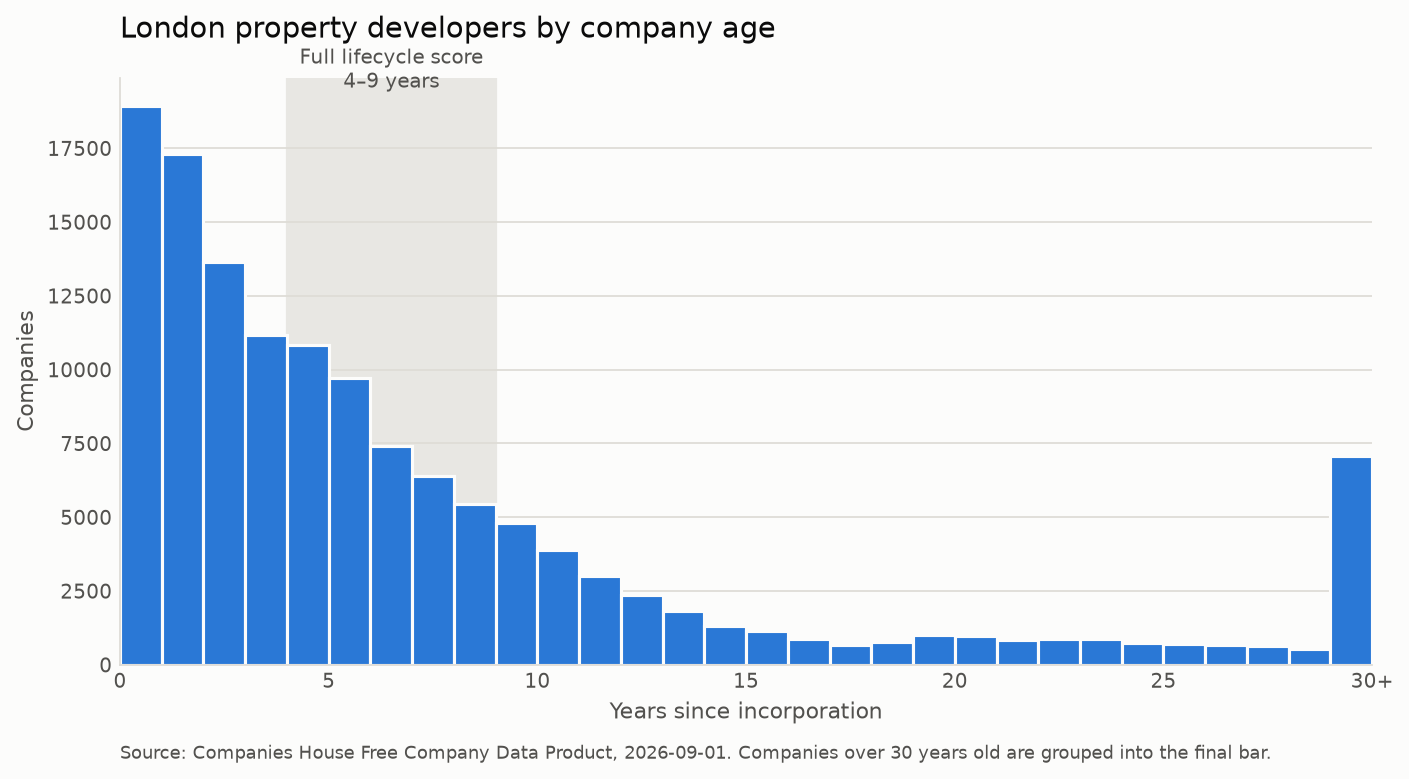

In [4]:
from IPython.display import Image

Image(filename=config.OUTPUT_DIR + "/segment_age.png")

## Reading the score back

A score a salesperson cannot decompose is a score they will not trust, so every component is carried
into the output alongside the total. Here is the top account broken back down into the four numbers
that produced it.

In [5]:
best = accounts.iloc[0]
print(best["CompanyName"], "-", best["Score"], "points")
print()
for component, weight in config.WEIGHTS.items():
    column = {"industry_fit": "IndustryFit", "lifecycle_fit": "LifecycleFit",
              "commercial_substance": "CommercialSubstance",
              "filing_health": "FilingHealth"}[component]
    print(f"  {component:22} {best[column]:.3f} x {weight:2d} = {best[column] * weight:5.1f}")

SIBNER GROUP LTD - 100.0 points

  industry_fit           1.000 x 35 =  35.0
  lifecycle_fit          1.000 x 25 =  25.0
  commercial_substance   1.000 x 25 =  25.0
  filing_health          1.000 x 15 =  15.0


## What the ranking is not

Three honest limits, stated here rather than left for a hiring manager to find:

1. **No revenue data.** Companies House publishes no turnover for small companies. Substance is
   inferred from accounts category and charge count, which are proxies, not measurements.
2. **Registered address, not trading address.** Some of these developers build nowhere near London.
3. **Self-declared SIC codes.** Nobody audits them, and a company that changed business four years ago
   often never updated the register.

None of these are fatal for the job the list does — putting 25 plausible names in front of a
salesperson in priority order. All three would be fatal if the score were presented as a
qualification decision rather than a **prioritisation** one.